In [8]:
import numpy as np
import pandas as pd
import joblib
import torch
import matplotlib.pyplot as plt


In [9]:
BASE_PATH = r"C:\Users\Agastya\Hbb-jet-tagging"

DATA_PROCESSED = BASE_PATH + r"\data\processed"
ARTIFACTS      = BASE_PATH + r"\artifacts"

TRAIN_PARQUET = DATA_PROCESSED + r"\train.parquet"
TEST_PARQUET  = DATA_PROCESSED + r"\test.parquet"

LOGREG_PATH = ARTIFACTS + r"\logreg_baseline.pkl"
XGB_PATH    = ARTIFACTS + r"\xgb_baseline.pkl"
MLP_PATH    = ARTIFACTS + r"\mlp.pt"


In [10]:
import pandas as pd

TRAIN_PARQUET = r"C:\Users\Agastya\Hbb-jet-tagging\data\processed\train.parquet"

df_train = pd.read_parquet(TRAIN_PARQUET)

label_col = "label_H_bb"
print(df_train.shape)
df_train.head()


(199711, 22)


,fj_pt,fj_sdmass,fj_sdn2,fj_n_sdsubjets,fj_tau1,fj_tau2,fj_tau3,fj_ptDR,fj_relptdiff,fj_jetNTracks,...,fj_sdsj1_mult,fj_sdsj1_ptD,fj_mass,fj_eta,fj_phi,fj_sdsj1_eta,fj_sdsj1_mass,label_H_bb,tau21,tau32
0,448.633636,4.911332,0.000073,2.0,0.067988,0.059589,0.044930,11.378714,0.678625,10.0,...,6.0,0.525917,68.060570,-0.277724,-2.183877,-0.280709,3.302880,0,0.876467,0.753994
1,868.861389,34.992409,0.001675,2.0,0.111101,0.087648,0.072055,112.677155,0.716411,21.0,...,19.0,0.412773,161.474731,-0.716812,2.365500,-0.708606,19.311876,0,0.788904,0.822090
2,573.674377,13.481631,0.000554,2.0,0.073106,0.061262,0.049685,27.063063,0.471265,7.0,...,9.0,0.682750,86.054962,0.219193,0.296306,0.219143,6.023303,0,0.837985,0.811027
3,206.318527,18.484650,0.005919,2.0,0.132059,0.086257,0.064672,42.051800,0.711401,17.0,...,13.0,0.331445,35.347668,0.336462,2.244762,0.337573,11.302593,0,0.653168,0.749767
4,1068.199097,99.316536,0.012706,2.0,0.116926,0.040401,0.032547,195.188263,0.251499,15.0,...,19.0,0.360593,139.384796,0.889782,-2.385019,0.917607,22.814959,1,0.345525,0.805614


In [11]:
import joblib
import torch
import torch.nn as nn
import numpy as np

ARTIFACTS = r"C:\Users\Agastya\Hbb-jet-tagging\artifacts"

logreg = joblib.load(ARTIFACTS + r"\logreg_baseline.pkl")
xgb    = joblib.load(ARTIFACTS + r"\xgb_baseline.pkl")
scaler = joblib.load(ARTIFACTS + r"\scaler.pkl")


c:\Users\Agastya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Agastya\AppData\Local\Programs\Python\Python313\Lib\pickle.py:1760: UserWarning: [18:07:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving mod

In [12]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

mlp = MLP(input_dim=len(scaler.feature_names_in_))
mlp.load_state_dict(
    torch.load(ARTIFACTS + r"\mlp.pt", map_location="cpu")
)
mlp.eval()


MLP(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [13]:
feature_cols = scaler.feature_names_in_

X_scaled = scaler.transform(df_train[feature_cols])
df_train["score_logreg"] = logreg.predict_proba(X_scaled)[:, 1]
df_train["score_xgb"]    = xgb.predict_proba(X_scaled)[:, 1]

with torch.no_grad():
    logits = mlp(torch.tensor(X_scaled, dtype=torch.float32))
    df_train["score_mlp"] = torch.sigmoid(logits).numpy()



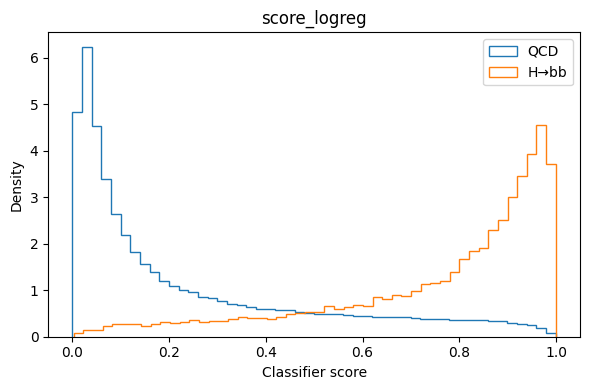

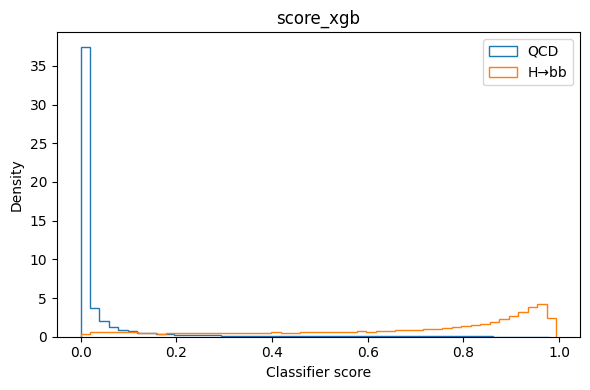

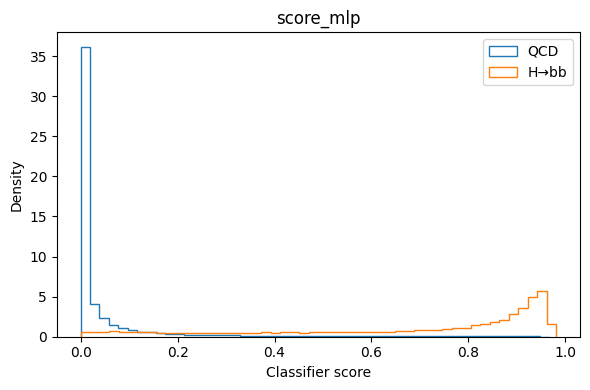

In [14]:
import matplotlib.pyplot as plt

for score in ["score_logreg", "score_xgb", "score_mlp"]:
    plt.figure(figsize=(6, 4))
    plt.hist(
        df_train[df_train[label_col] == 0][score],
        bins=50, density=True, histtype="step", label="QCD"
    )
    plt.hist(
        df_train[df_train[label_col] == 1][score],
        bins=50, density=True, histtype="step", label="H→bb"
    )
    plt.xlabel("Classifier score")
    plt.ylabel("Density")
    plt.title(score)
    plt.legend()
    plt.tight_layout()
    plt.show()


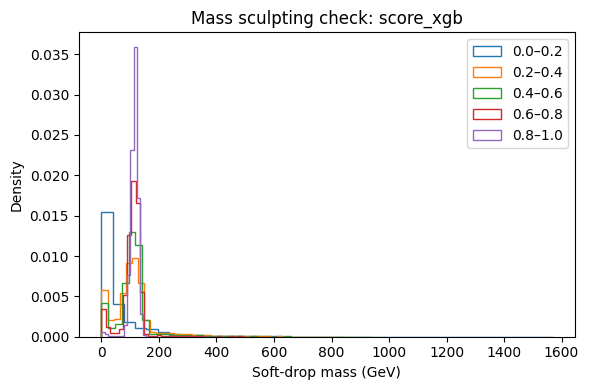

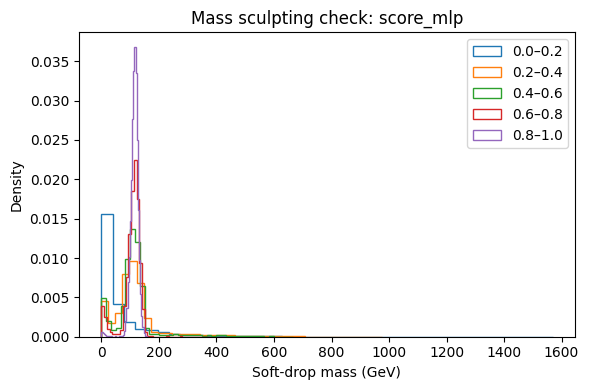

In [15]:
import numpy as np

def plot_mass_vs_score(df, score_col):
    bins = np.linspace(0, 1, 6)

    plt.figure(figsize=(6, 4))
    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i + 1]
        sel = (df[score_col] >= lo) & (df[score_col] < hi)

        plt.hist(
            df.loc[sel, "fj_sdmass"],
            bins=40,
            density=True,
            histtype="step",
            label=f"{lo:.1f}–{hi:.1f}"
        )

    plt.xlabel("Soft-drop mass (GeV)")
    plt.ylabel("Density")
    plt.title(f"Mass sculpting check: {score_col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_mass_vs_score(df_train, "score_xgb")
plot_mass_vs_score(df_train, "score_mlp")


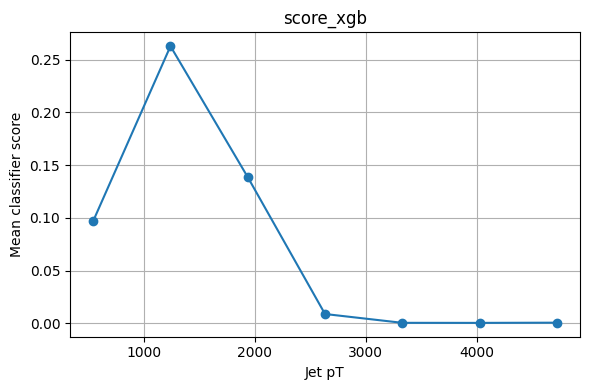

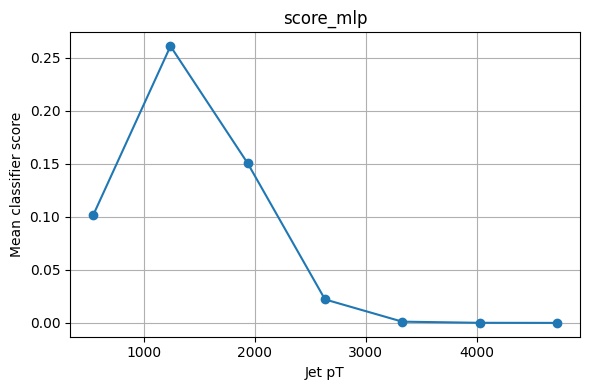

In [16]:
def plot_score_vs_pt(df, score_col):
    pt_bins = np.linspace(df["fj_pt"].min(), df["fj_pt"].max(), 8)

    means, centers = [], []

    for i in range(len(pt_bins) - 1):
        lo, hi = pt_bins[i], pt_bins[i + 1]
        sel = (df["fj_pt"] >= lo) & (df["fj_pt"] < hi)

        means.append(df.loc[sel, score_col].mean())
        centers.append(0.5 * (lo + hi))

    plt.figure(figsize=(6, 4))
    plt.plot(centers, means, marker="o")
    plt.xlabel("Jet pT")
    plt.ylabel("Mean classifier score")
    plt.title(score_col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_score_vs_pt(df_train, "score_xgb")
plot_score_vs_pt(df_train, "score_mlp")


In [17]:
from scipy.stats import ks_2samp

print("KS test on model outputs")
print("-" * 40)

for score in ["score_logreg", "score_xgb", "score_mlp"]:
    sig = df_train[df_train[label_col] == 1][score]
    bkg = df_train[df_train[label_col] == 0][score]

    ks, pval = ks_2samp(sig, bkg)
    print(f"{score:12s} | KS = {ks:.3f}")


KS test on model outputs
----------------------------------------
score_logreg | KS = 0.654
score_xgb    | KS = 0.840
score_mlp    | KS = 0.821


In [18]:
import pandas as pd
TEST_PARQUET = r"C:\Users\Agastya\Hbb-jet-tagging\data\processed\test.parquet"
df_test = pd.read_parquet(TEST_PARQUET)


In [19]:
import joblib

ARTIFACTS = r"C:\Users\Agastya\Hbb-jet-tagging\artifacts"

scaler = joblib.load(ARTIFACTS + r"\scaler.pkl")
print("Scaler loaded")


Scaler loaded


c:\Users\Agastya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [20]:
logreg = joblib.load(ARTIFACTS + r"\logreg_baseline.pkl")
xgb    = joblib.load(ARTIFACTS + r"\xgb_baseline.pkl")


c:\Users\Agastya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [21]:
X_test_scaled = scaler.transform(df_test[feature_cols])


In [22]:
# Classical models
df_test["score_logreg"] = logreg.predict_proba(X_test_scaled)[:, 1]
df_test["score_xgb"]    = xgb.predict_proba(X_test_scaled)[:, 1]

# MLP
mlp.eval()
with torch.no_grad():
    logits = mlp(torch.tensor(X_test_scaled, dtype=torch.float32))
    df_test["score_mlp"] = torch.sigmoid(logits).numpy()


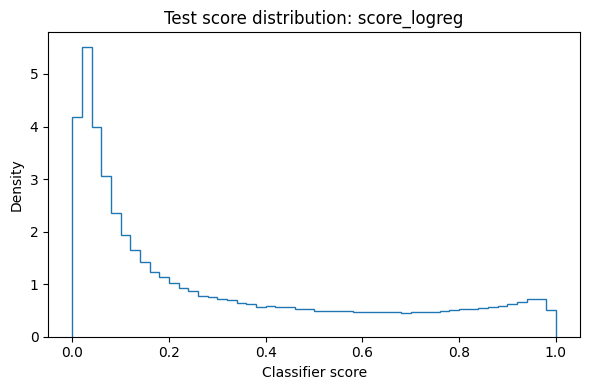

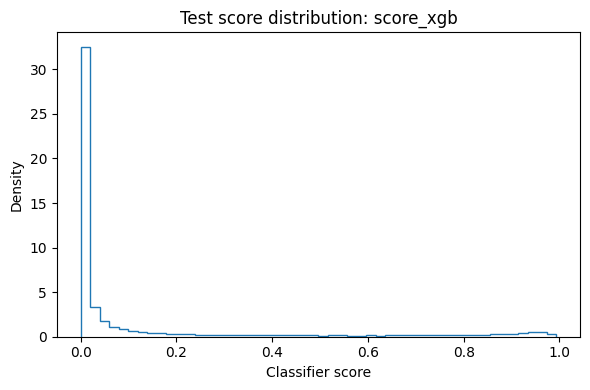

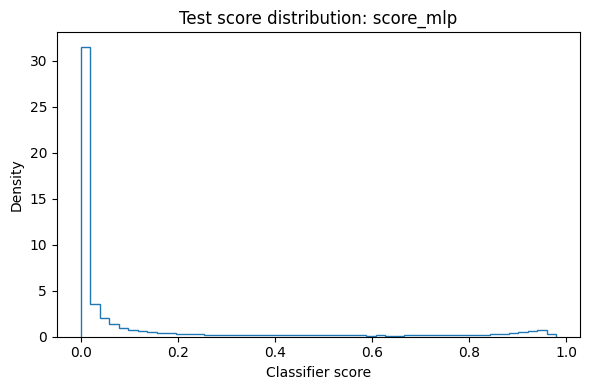

In [23]:
import matplotlib.pyplot as plt

for score in ["score_logreg", "score_xgb", "score_mlp"]:
    plt.figure(figsize=(6, 4))
    plt.hist(df_test[score], bins=50, density=True, histtype="step")
    plt.xlabel("Classifier score")
    plt.ylabel("Density")
    plt.title(f"Test score distribution: {score}")
    plt.tight_layout()
    plt.show()


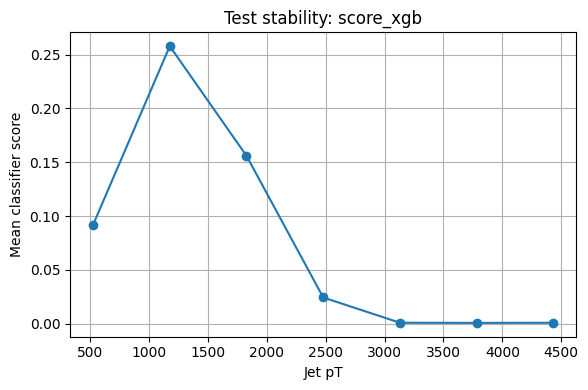

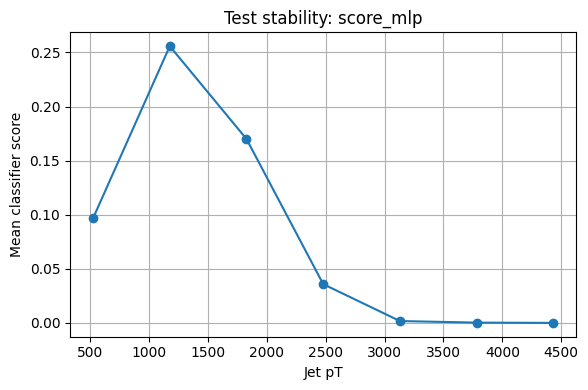

In [24]:
import numpy as np

def plot_score_vs_pt_test(df, score_col):
    pt_bins = np.linspace(df["fj_pt"].min(), df["fj_pt"].max(), 8)
    means, centers = [], []

    for i in range(len(pt_bins) - 1):
        lo, hi = pt_bins[i], pt_bins[i + 1]
        sel = (df["fj_pt"] >= lo) & (df["fj_pt"] < hi)

        means.append(df.loc[sel, score_col].mean())
        centers.append(0.5 * (lo + hi))

    plt.figure(figsize=(6, 4))
    plt.plot(centers, means, marker="o")
    plt.xlabel("Jet pT")
    plt.ylabel("Mean classifier score")
    plt.title(f"Test stability: {score_col}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_score_vs_pt_test(df_test, "score_xgb")
plot_score_vs_pt_test(df_test, "score_mlp")


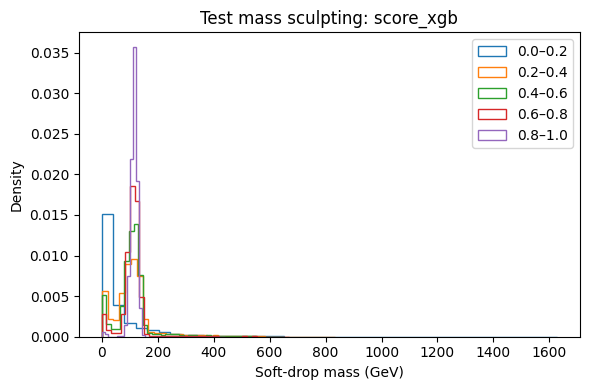

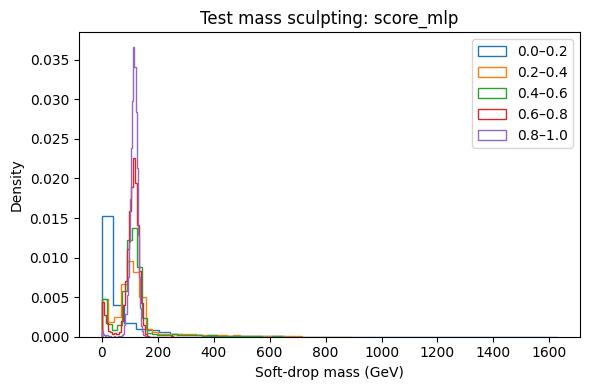

In [25]:
def plot_mass_vs_score_test(df, score_col):
    bins = np.linspace(0, 1, 6)

    plt.figure(figsize=(6, 4))
    for i in range(len(bins) - 1):
        lo, hi = bins[i], bins[i + 1]
        sel = (df[score_col] >= lo) & (df[score_col] < hi)

        plt.hist(
            df.loc[sel, "fj_sdmass"],
            bins=40,
            density=True,
            histtype="step",
            label=f"{lo:.1f}–{hi:.1f}"
        )

    plt.xlabel("Soft-drop mass (GeV)")
    plt.ylabel("Density")
    plt.title(f"Test mass sculpting: {score_col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_mass_vs_score_test(df_test, "score_xgb")
plot_mass_vs_score_test(df_test, "score_mlp")


In [26]:
X_test_scaled = scaler.transform(df_test[feature_cols])

df_test["score_logreg"] = logreg.predict_proba(X_test_scaled)[:, 1]
df_test["score_xgb"]    = xgb.predict_proba(X_test_scaled)[:, 1]

with torch.no_grad():
    logits = mlp(torch.tensor(X_test_scaled, dtype=torch.float32))
    df_test["score_mlp"] = torch.sigmoid(logits).numpy()


In [28]:
from sklearn.metrics import roc_auc_score, accuracy_score

print("FINAL TRAIN METRICS")
print("-" * 40)

y = df_train[label_col].values

for score in ["score_logreg", "score_xgb", "score_mlp"]:
    probs = df_train[score].values
    auc = roc_auc_score(y, probs)
    acc = accuracy_score(y, (probs > 0.5).astype(int))
    print(f"{score:15s} | AUC = {auc:.4f} | Acc = {acc:.4f}")


FINAL TRAIN METRICS
----------------------------------------
score_logreg    | AUC = 0.9049 | Acc = 0.8179
score_xgb       | AUC = 0.9769 | Acc = 0.9503
score_mlp       | AUC = 0.9711 | Acc = 0.9463
